# Robot Data Wrangling
## Part 2 — Shops and Robots

### Objective
Create the two tables specified in the instructor's diagram and
combine them using Shop_ID.

### Data Sources and Assumptions
- Timestamp and Axis1–Axis6 come from the original recording.
- Robot_ID identifies the recording as RMBR4-2.
- Shop assignments, takt values, and the example IP address are synthetic.
- Takt is expressed in seconds per unit.
- Only SH01 has recorded robot measurements.

### Table Relationship
Shops.Shop_ID is unique. Multiple robot measurements reference one shop.

Robot_ID identifies the robot but repeats across measurements.
For this time-series table, Robot_ID and Timestamp together identify
a measurement.

### 1. Create the Shops Table

In [1]:
import pandas as pd
from IPython.display import display

# Create a small synthetic shop catalog.
# Takt values are illustrative demand targets in seconds per unit.
shops = pd.DataFrame({
    "Shop_ID": ["SH01", "SH02", "SH03"],
    "Takt": [120, 90, 150],
})

# Check that each shop has a unique identifier and a positive takt.
assert shops["Shop_ID"].notna().all()
assert shops["Shop_ID"].is_unique
assert shops["Takt"].gt(0).all()

display(shops)

,Shop_ID,Takt
0,SH01,120
1,SH02,90
2,SH03,150


### Timestamp Parsing Rule

CSV files store timestamps as text. After export, ISO 8601 timestamps
may contain different levels of fractional-second precision.

We explicitly use `format="ISO8601"` to support these variations
without relying on automatic format inference.

- `utc=True` produces consistent timezone-aware timestamps.
- `errors="raise"` stops execution if an invalid value is found.
- Missing timestamps are rejected by a separate validation.
- No timestamps are silently removed, filled, or replaced.

This parsing rule is part of the reproducible workflow and does not
require manually editing the source CSV.

### 2. Create the Robots Table

Load the six-channel dataset exported in Part 1 and adapt its column
names to the instructor's structure.

- Robot_ID: RMBR4-2, identified from the source filename.
- IP_ADDRESS: a documentation-only example, not the robot's actual address.
- Shop_ID: SH01, a synthetic assignment for this exercise.

All original timestamps and selected current measurements are preserved.
The combination of Robot_ID and Timestamp must be unique.

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Locate the exported dataset without relying on variables from Part 1.
relative_path = Path(
    "data/processed/electrical_current_six_channels.csv"
)
current_folder = Path.cwd()

if (current_folder / relative_path).is_file():
    project_root = current_folder
elif (current_folder.parent / relative_path).is_file():
    project_root = current_folder.parent
else:
    raise FileNotFoundError(
        "Run the export section in Part 1 before continuing."
    )

source = pd.read_csv(project_root / relative_path)

# Define the channel names required by the instructor's diagram.
axis_mapping = {
    f"Axis #{number}": f"Axis{number}"
    for number in range(1, 7)
}

# Check the input structure before selecting columns.
required_columns = ["Timestamp", "Trait"] + list(axis_mapping)
missing_columns = [
    column for column in required_columns
    if column not in source.columns
]

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

# Confirm that all records contain electrical-current measurements.
if not source["Trait"].eq("current").fillna(False).all():
    raise ValueError("Unexpected or missing measurement types found.")

# Create an independent copy and standardize the six channel names.
robots = source[
    ["Timestamp"] + list(axis_mapping)
].rename(columns=axis_mapping).copy()

# CSV timestamps may contain different fractional-second precision.
# Parse ISO 8601 explicitly, preserve UTC, and reject invalid values.
robots["Timestamp"] = pd.to_datetime(
    robots["Timestamp"],
    format="ISO8601",
    utc=True,
    errors="raise",
)

# Reject missing timestamps without deleting or filling measurements.
if robots["Timestamp"].isna().any():
    raise ValueError("Missing timestamps must be investigated.")

# Use the source filename to identify the robot recording.
robots["Robot_ID"] = "RMBR4-2"

# Add synthetic context for the exercise.
# This documentation-only IP address is not the robot's actual address.
robots["IP_ADDRESS"] = "192.0.2.10"
robots["Shop_ID"] = "SH01"

# Arrange the columns to match the instructor's diagram.
robots = robots[
    ["Robot_ID", "Timestamp"]
    + list(axis_mapping.values())
    + ["IP_ADDRESS", "Shop_ID"]
]

# Each robot and timestamp combination must identify one measurement.
if robots.duplicated(["Robot_ID", "Timestamp"]).any():
    raise ValueError("Duplicate robot/timestamp combinations found.")

# Validate the foreign key against the Shops table created in Section 1.
if not robots["Shop_ID"].isin(shops["Shop_ID"]).all():
    raise ValueError("A robot references a shop absent from the catalog.")

# Confirm that no source records were lost during preparation.
if len(robots) != len(source):
    raise ValueError("The number of measurements changed unexpectedly.")

print(f"Robot measurements: {len(robots):,}")
print(f"Columns: {robots.shape[1]}")
print("Timestamp parsing and relationship checks passed.")

display(robots.head())

Robot measurements: 39,672
Columns: 10
Timestamp parsing and relationship checks passed.


,Robot_ID,Timestamp,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6,IP_ADDRESS,Shop_ID
0,RMBR4-2,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01
1,RMBR4-2,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01
2,RMBR4-2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01
3,RMBR4-2,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01
4,RMBR4-2,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01


### 3. Merge Robots with Shops

Use a left merge to preserve every robot measurement and add the
corresponding shop's synthetic takt value.

The relationship is many-to-one: many measurements reference one
unique shop record.

- `validate="many_to_one"` rejects duplicate shop keys.
- `indicator=True` identifies matched and unmatched measurements.
- The merge must preserve the measurement count and original values.

SH02 and SH03 have no robot measurements and therefore do not appear
in this left-merge result.

Takt provides synthetic demand context; it does not establish actual
cycle times or production performance.

In [3]:
# Reject missing join keys before merging.
# Pandas can match null keys, which would be inappropriate here.
if robots["Shop_ID"].isna().any() or shops["Shop_ID"].isna().any():
    raise ValueError("Shop_ID must not contain missing values.")

# Enrich each measurement with its shop's synthetic takt.
merge_result = pd.merge(
    robots,
    shops,
    on="Shop_ID",
    how="left",
    validate="many_to_one",
    indicator=True,
    sort=False,
)

# Summarize whether measurements found a matching shop.
print("Merge matching summary:")
display(
    merge_result["_merge"]
    .value_counts()
    .rename_axis("MatchStatus")
    .to_frame("Rows")
)

# Confirm that the merge preserved every measurement.
if len(merge_result) != len(robots):
    raise ValueError("The merge changed the measurement count.")

if not merge_result["_merge"].eq("both").all():
    raise ValueError("Some measurements have no matching shop.")

# Verify that all original robot columns and values remain unchanged.
pd.testing.assert_frame_equal(
    merge_result[robots.columns].reset_index(drop=True),
    robots.reset_index(drop=True),
)

# Keep the audit indicator in merge_result and remove it from the
# analysis table, leaving only the requested data columns.
robots_with_shop = merge_result.drop(columns="_merge").copy()

print(f"Merged measurements: {len(robots_with_shop):,}")
print(f"Columns: {robots_with_shop.shape[1]}")
print("Merge checks passed.")

display(
    robots_with_shop[
        ["Robot_ID", "Timestamp", "Shop_ID", "Takt", "Axis1", "Axis2"]
    ].head()
)

Merge matching summary:


,Rows
MatchStatus,
both,39672
left_only,0
right_only,0


Merged measurements: 39,672
Columns: 11
Merge checks passed.


,Robot_ID,Timestamp,Shop_ID,Takt,Axis1,Axis2
0,RMBR4-2,2022-10-17 12:18:23.660000+00:00,SH01,120,0.0,0.0
1,RMBR4-2,2022-10-17 12:18:25.472000+00:00,SH01,120,0.0,0.0
2,RMBR4-2,2022-10-17 12:18:27.348000+00:00,SH01,120,0.0,0.0
3,RMBR4-2,2022-10-17 12:18:29.222000+00:00,SH01,120,0.0,0.0
4,RMBR4-2,2022-10-17 12:18:31.117000+00:00,SH01,120,0.0,0.0


### 4. Compare Merge Types

Keep Robots as the left table and Shops as the right table.

- **Left:** preserves all robot measurements.
- **Inner:** keeps only matching records.
- **Right:** preserves all shops, including shops without measurements.
- **Outer:** preserves matching and unmatched records from both tables.

All measurements belong to SH01. SH02 and SH03 have no measurements,
so right and outer merges include one unmatched row for each.

Missing robot values in these unmatched rows mean that no measurement
was supplied. They must not be replaced with zero.

In [4]:
# Compare join behavior using the same tables and key.
comparison_rows = []
merge_examples = {}

for merge_type in ["left", "inner", "right", "outer"]:
    result = pd.merge(
        robots,
        shops,
        on="Shop_ID",
        how=merge_type,
        validate="many_to_one",
        indicator=True,
    )

    merge_examples[merge_type] = result

    comparison_rows.append({
        "MergeType": merge_type,
        "TotalRows": len(result),
        "MatchedRows": int(result["_merge"].eq("both").sum()),
        "RobotOnlyRows": int(result["_merge"].eq("left_only").sum()),
        "ShopOnlyRows": int(result["_merge"].eq("right_only").sum()),
    })

merge_comparison = pd.DataFrame(comparison_rows)
display(merge_comparison)

# Inspect shops that have no corresponding robot measurements.
outer_result = merge_examples["outer"]

print("Shops without robot measurements:")
display(
    outer_result.loc[
        outer_result["_merge"].eq("right_only"),
        ["Shop_ID", "Takt", "Robot_ID", "Timestamp", "_merge"],
    ]
)

# Keep robots_with_shop from Section 3 as the main analysis dataset.
# The comparison tables demonstrate join behavior only.

,MergeType,TotalRows,MatchedRows,RobotOnlyRows,ShopOnlyRows
0,left,39672,39672,0,0
1,inner,39672,39672,0,0
2,right,39674,39672,0,2
3,outer,39674,39672,0,2


Shops without robot measurements:


,Shop_ID,Takt,Robot_ID,Timestamp,_merge
39672,SH02,90,NaN,NaT,right_only
39673,SH03,150,NaN,NaT,right_only


### 5. Merge Findings and Export

All 39,672 robot measurements matched SH01 successfully.

Left and inner merges contain the same measurements because every
robot record has a valid shop reference. Right and outer merges also
include SH02 and SH03, which have no recorded measurements.

Missing robot values for those shops represent absent measurements,
not zero current.

Export the two source tables, the enriched measurement table, and
the merge comparison. Synthetic shop assignments, IP addresses,
and takt values remain educational assumptions.

Rerunning this section refreshes these generated files without
modifying the original recording.

In [5]:
# Store generated tables separately from the original recording.
workshop_dir = project_root / "data" / "workshop"
merge_report_dir = project_root / "reports" / "merge_analysis"

workshop_dir.mkdir(parents=True, exist_ok=True)
merge_report_dir.mkdir(parents=True, exist_ok=True)

# Export the two tables specified in the instructor's diagram.
shops.to_csv(workshop_dir / "shops.csv", index=False)
robots.to_csv(workshop_dir / "robots.csv", index=False)

# Export the left-merge result for subsequent preprocessing exercises.
robots_with_shop.to_csv(
    workshop_dir / "robots_with_shop.csv",
    index=False,
)

# Save evidence of the four merge behaviors.
merge_comparison.to_csv(
    merge_report_dir / "merge_comparison.csv",
    index=False,
)

# Export unmatched shops as catalog records, not robot measurements.
shops_without_measurements = shops.loc[
    ~shops["Shop_ID"].isin(robots["Shop_ID"])
].copy()

shops_without_measurements.to_csv(
    merge_report_dir / "shops_without_measurements.csv",
    index=False,
)

print("Workshop tables and merge reports saved.")
print("Table folder:", workshop_dir)
print("Report folder:", merge_report_dir)

Workshop tables and merge reports saved.
Table folder: C:\AI\PROG8245\WranglingWorkshop\data\workshop
Report folder: C:\AI\PROG8245\WranglingWorkshop\reports\merge_analysis


### Preview of the Merged Table

The first five rows below show the original robot measurements
enriched with the shop's synthetic takt value.

Shop_ID links the two tables. Takt comes from Shops; all original
robot measurement values are preserved.

In [6]:
# Show all columns so the result of the merge is visible.
print("Merged table — first five rows")
print("Takt is expressed in seconds per unit.")

with pd.option_context(
    "display.max_columns", None,
    "display.expand_frame_repr", False,
):
    display(robots_with_shop.head(5))

Merged table — first five rows
Takt is expressed in seconds per unit.


,Robot_ID,Timestamp,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6,IP_ADDRESS,Shop_ID,Takt
0,RMBR4-2,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01,120
1,RMBR4-2,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01,120
2,RMBR4-2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01,120
3,RMBR4-2,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01,120
4,RMBR4-2,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,192.0.2.10,SH01,120


### 6. Inspect the Merged Data Before Preprocessing

Check data types and missing values in the left-merge result.

Cleaning decisions must follow the observed data:
- Preserve recorded zeros.
- Do not fill values when no data is missing.
- Keep timestamps as UTC datetime values.
- Confirm that axis measurements and Takt are numeric.

Missing robot values in the separate outer-merge example represent
shops without measurements and must not be treated as zero current.

In [7]:
# Summarize the types and completeness of the merged analysis table.
merged_quality = pd.DataFrame({
    "DataType": robots_with_shop.dtypes.astype(str),
    "MissingCount": robots_with_shop.isna().sum(),
    "MissingPercent": (
        robots_with_shop.isna().mean() * 100
    ).round(2),
})
merged_quality.index.name = "Column"

display(merged_quality)

# Check the numerical columns without altering recorded values.
measurement_columns = [f"Axis{number}" for number in range(1, 7)]
numeric_columns = measurement_columns + ["Takt"]

non_numeric_columns = [
    column for column in numeric_columns
    if not pd.api.types.is_numeric_dtype(robots_with_shop[column])
]

if non_numeric_columns:
    raise TypeError(
        f"Numeric conversion is required for: {non_numeric_columns}"
    )

# Report whether missing-value treatment is actually necessary.
total_missing = int(robots_with_shop.isna().sum().sum())

print(f"Total missing values: {total_missing}")

if total_missing == 0:
    print("No imputation is needed. All values are preserved.")
else:
    print("Review missing values by column before choosing a treatment.")

# Count recorded zeros separately from missing values.
display(
    robots_with_shop[measurement_columns]
    .eq(0)
    .sum()
    .rename_axis("Channel")
    .to_frame("ZeroCount")
)

,DataType,MissingCount,MissingPercent
Column,,,
Robot_ID,str,0,0.0
Timestamp,"datetime64[us, UTC]",0,0.0
Axis1,float64,0,0.0
Axis2,float64,0,0.0
Axis3,float64,0,0.0
Axis4,float64,0,0.0
Axis5,float64,0,0.0
Axis6,float64,0,0.0
IP_ADDRESS,str,0,0.0


Total missing values: 0
No imputation is needed. All values are preserved.


,ZeroCount
Channel,
Axis1,25914
Axis2,25822
Axis3,25844
Axis4,26004
Axis5,25864
Axis6,26073


### 7. Create Measurement-Based Features

Create two features from the six recorded axis channels:

- `NonZeroAxisCount`: number of channels with a nonzero reading.
- `AllAxesZero`: whether all six channels record zero simultaneously.

These features describe measurements only. They do not confirm
robot motion, production, or downtime.

All six measurements must be present and numeric before calculating
these features. The original axis values remain unchanged.

In [8]:
# Select the six original measurement columns.
measurement_columns = [f"Axis{number}" for number in range(1, 7)]
axis_values = robots_with_shop[measurement_columns]

# Reject incomplete or nonnumeric readings before deriving features.
if axis_values.isna().any().any():
    raise ValueError("Resolve missing axis measurements before continuing.")

if not all(
    pd.api.types.is_numeric_dtype(axis_values[column])
    for column in measurement_columns
):
    raise TypeError("All axis measurements must be numeric.")

# Create a separate analysis table, preserving the merged source table.
robots_features = robots_with_shop.copy()

# Count nonzero readings; do not interpret them as confirmed movement.
robots_features["NonZeroAxisCount"] = axis_values.ne(0).sum(axis=1)
robots_features["AllAxesZero"] = axis_values.eq(0).all(axis=1)

# Display the new features first, followed by join keys and context.
preview_columns = [
    "NonZeroAxisCount",
    "AllAxesZero",
    "Shop_ID",
    "Takt",
    "Robot_ID",
    "Timestamp",
] + measurement_columns

print("New features — first five measurements:")
display(robots_features[preview_columns].head(5))

# Summarize the distribution across observed samples.
# Sample percentages are not percentages of elapsed operating time.
feature_summary = (
    robots_features["NonZeroAxisCount"]
    .value_counts()
    .reindex(range(7), fill_value=0)
    .sort_index()
    .rename_axis("NonZeroAxisCount")
    .to_frame("SampleCount")
)

feature_summary["SamplePercent"] = (
    feature_summary["SampleCount"] / len(robots_features) * 100
).round(2)

print("Distribution of nonzero channel counts:")
display(feature_summary)

New features — first five measurements:


,NonZeroAxisCount,AllAxesZero,Shop_ID,Takt,Robot_ID,Timestamp,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6
0,0,True,SH01,120,RMBR4-2,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
1,0,True,SH01,120,RMBR4-2,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2,0,True,SH01,120,RMBR4-2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
3,0,True,SH01,120,RMBR4-2,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
4,0,True,SH01,120,RMBR4-2,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0


Distribution of nonzero channel counts:


,SampleCount,SamplePercent
NonZeroAxisCount,,
0,25577,64.47
1,82,0.21
2,116,0.29
3,105,0.26
4,99,0.25
5,672,1.69
6,13021,32.82


### 8. Visualize Simultaneous Nonzero Readings

The distribution is concentrated at two extremes: all six channels
record zero, or all six record nonzero values.

The chart shows percentages of recorded samples, not percentages of
operating time. These patterns do not establish production or downtime.

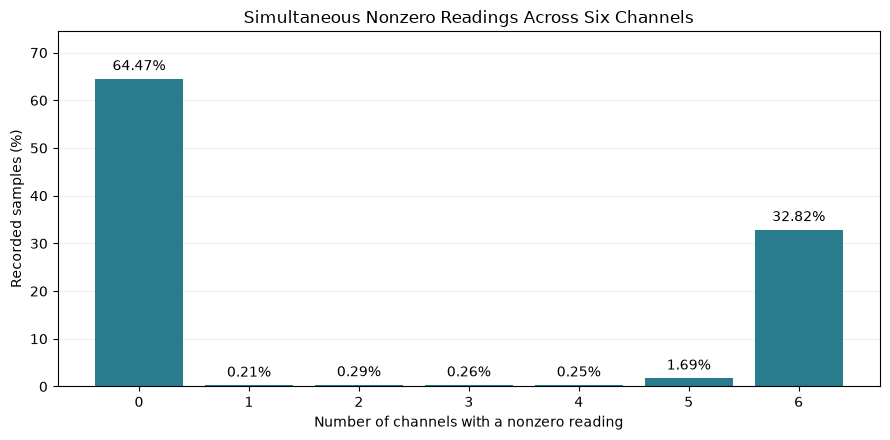

Feature table, summary, and chart saved.


In [9]:
import matplotlib.pyplot as plt

# Plot the feature calculated in Section 7.
# Use sample percentages because the sampling intervals are not uniform.
fig_features, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(
    feature_summary.index,
    feature_summary["SamplePercent"],
    color="#287C8E",
)

# Label every category so small percentages remain readable.
ax.bar_label(
    bars,
    labels=[
        f"{percentage:.2f}%"
        for percentage in feature_summary["SamplePercent"]
    ],
    padding=4,
)

ax.set_title("Simultaneous Nonzero Readings Across Six Channels")
ax.set_xlabel("Number of channels with a nonzero reading")
ax.set_ylabel("Recorded samples (%)")
ax.set_xticks(range(7))
ax.set_ylim(0, feature_summary["SamplePercent"].max() + 10)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

fig_features.tight_layout()
plt.show()

# Save the chart and the complete feature table for reproducibility.
feature_report_dir = project_root / "reports" / "feature_analysis"
feature_report_dir.mkdir(parents=True, exist_ok=True)

fig_features.savefig(
    feature_report_dir / "nonzero_channel_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

feature_summary.to_csv(
    feature_report_dir / "nonzero_channel_distribution.csv"
)

# Place the derived features and merge columns first in the exported table.
export_columns = [
    "NonZeroAxisCount", "AllAxesZero", "Shop_ID", "Takt",
    "Robot_ID", "Timestamp",
] + measurement_columns + ["IP_ADDRESS"]

robots_features[export_columns].to_csv(
    workshop_dir / "robots_with_features.csv",
    index=False,
)

print("Feature table, summary, and chart saved.")

### 9. Build an Hourly Pivot Table

Create `HourUTC` by rounding each timestamp down to the beginning
of its hour, preserving the date and UTC timezone.

Use `pivot_table()` to calculate the mean recorded current for each
axis within each hourly group. Include the sample count as context.

These are sample-based means, not time-weighted averages.
The first and last hours cover only part of an hour, and sampling
gaps can affect coverage. Recorded zeros remain included.

Hourly grouping — first five rows:


,HourUTC,Shop_ID,Timestamp,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6
0,2022-10-17 12:00:00+00:00,SH01,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:00:00+00:00,SH01,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:00:00+00:00,SH01,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:00:00+00:00,SH01,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:00:00+00:00,SH01,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0


Hourly pivot table — first five rows:


,HourUTC,Shop_ID,Robot_ID,SampleCount,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6
0,2022-10-17 12:00:00+00:00,SH01,RMBR4-2,1040,0.580,2.576,2.209,0.430,0.696,0.436
1,2022-10-17 13:00:00+00:00,SH01,RMBR4-2,1623,0.787,4.013,2.876,0.674,1.056,0.672
2,2022-10-17 14:00:00+00:00,SH01,RMBR4-2,1784,1.043,5.601,4.383,0.939,1.519,0.882
3,2022-10-17 15:00:00+00:00,SH01,RMBR4-2,1756,0.592,2.690,2.224,0.454,0.762,0.469
4,2022-10-17 16:00:00+00:00,SH01,RMBR4-2,1798,0.003,0.007,0.012,0.003,0.004,0.004


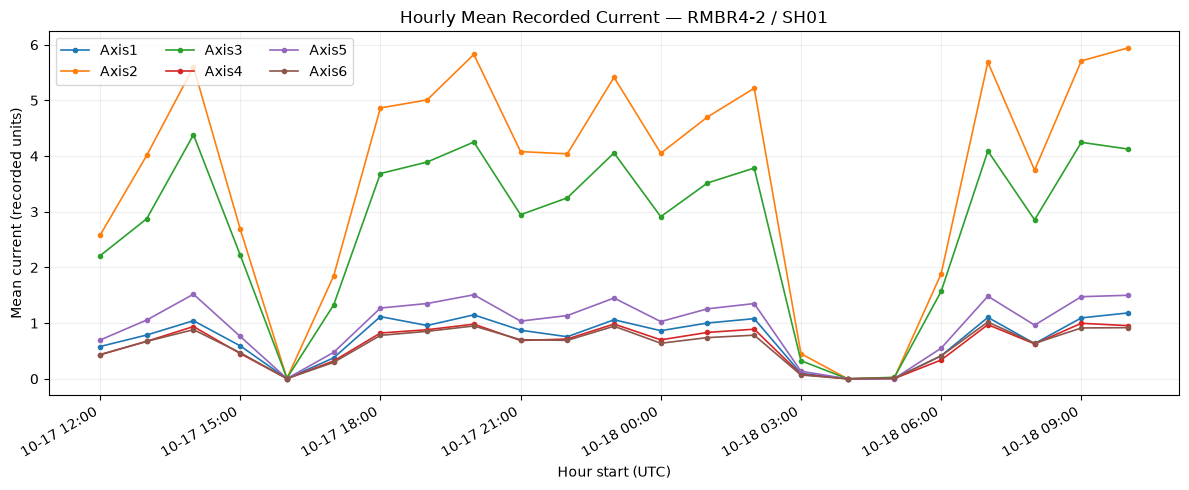

Hourly pivot table and chart saved.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create the hourly grouping variable, preserving the date and UTC.
measurement_columns = [f"Axis{number}" for number in range(1, 7)]
hourly_source = robots_features.copy()
hourly_source["HourUTC"] = hourly_source["Timestamp"].dt.floor("h")

# Display the new column first, followed by the merge key and context.
print("Hourly grouping — first five rows:")
display(
    hourly_source[
        ["HourUTC", "Shop_ID", "Timestamp"] + measurement_columns
    ].head(5)
)

# Calculate sample-based means, including recorded zeros.
hourly_pivot = hourly_source.pivot_table(
    index=["HourUTC", "Shop_ID", "Robot_ID"],
    values=measurement_columns,
    aggfunc="mean",
)

# Count observations to help interpret hourly coverage.
hourly_counts = (
    hourly_source.groupby(["HourUTC", "Shop_ID", "Robot_ID"])
    .size()
    .rename("SampleCount")
)

hourly_report = hourly_pivot.join(hourly_counts).reset_index()

hourly_report = hourly_report[
    ["HourUTC", "Shop_ID", "Robot_ID", "SampleCount"]
    + measurement_columns
]

# Round only current columns in a display copy.
# Keep timestamps unchanged and preserve full precision in the report.
hourly_preview = hourly_report.head(5).copy()
hourly_preview[measurement_columns] = (
    hourly_preview[measurement_columns].round(3)
)

print("Hourly pivot table — first five rows:")
display(hourly_preview)

# Prevent unrelated robots or shops from being combined in one plot.
if len(hourly_report[["Shop_ID", "Robot_ID"]].drop_duplicates()) != 1:
    raise ValueError("Create separate plots for each robot/shop pair.")

fig_hourly, ax = plt.subplots(figsize=(12, 5))

for channel in measurement_columns:
    ax.plot(
        hourly_report["HourUTC"],
        hourly_report[channel],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=channel,
    )

ax.set_title("Hourly Mean Recorded Current — RMBR4-2 / SH01")
ax.set_xlabel("Hour start (UTC)")
ax.set_ylabel("Mean current (recorded units)")
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d %H:%M", tz="UTC")
)
ax.legend(ncol=3)
ax.grid(alpha=0.2)

fig_hourly.autofmt_xdate()
fig_hourly.tight_layout()
plt.show()

# Export the full-precision report and chart.
hourly_report_dir = project_root / "reports" / "hourly_analysis"
hourly_report_dir.mkdir(parents=True, exist_ok=True)

hourly_report.to_csv(
    hourly_report_dir / "hourly_current_summary.csv",
    index=False,
)
fig_hourly.savefig(
    hourly_report_dir / "hourly_current_means.png",
    dpi=200,
    bbox_inches="tight",
)

print("Hourly pivot table and chart saved.")

### 10. Explore Correlation Between Axis Channels

Calculate Pearson correlations using the original six-channel readings,
including recorded zeros.

Correlation describes linear association, not causation. Shared zero
periods may influence the results.

Takt is excluded because it is constant for the only observed shop.
Its relationship with current cannot be estimated from this dataset.

Pearson correlation between recorded axis channels:


,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6
Axis1,1.000,0.312,0.371,0.389,0.363,0.291
Axis2,0.312,1.000,0.510,0.486,0.536,0.261
Axis3,0.371,0.510,1.000,0.434,0.419,0.397
Axis4,0.389,0.486,0.434,1.000,0.478,0.302
Axis5,0.363,0.536,0.419,0.478,1.000,0.303
Axis6,0.291,0.261,0.397,0.302,0.303,1.000


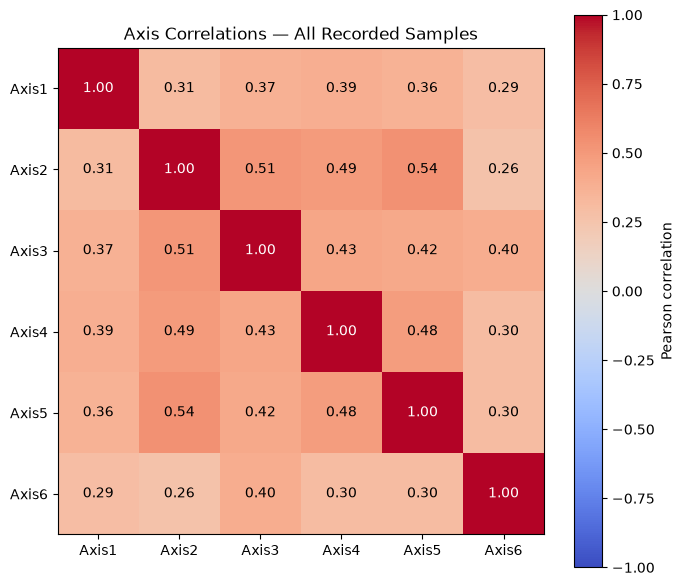

Correlation table and chart saved.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate correlations from individual readings, not hourly averages.
measurement_columns = [f"Axis{number}" for number in range(1, 7)]
axis_correlation = robots_with_shop[measurement_columns].corr(
    method="pearson"
)

print("Pearson correlation between recorded axis channels:")
display(axis_correlation.round(3))

# Use a fixed scale so colors represent the full correlation range.
fig_correlation, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    axis_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(6), measurement_columns)
ax.set_yticks(range(6), measurement_columns)
ax.set_title("Axis Correlations — All Recorded Samples")

# Label each cell to make the numerical results easy to read.
for row in range(6):
    for column in range(6):
        value = axis_correlation.iloc[row, column]
        label = f"{value:.2f}" if np.isfinite(value) else "N/A"
        ax.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 else "black",
        )

fig_correlation.colorbar(image, ax=ax, label="Pearson correlation")
fig_correlation.tight_layout()
plt.show()

# Save full-precision results and the annotated visualization.
correlation_dir = project_root / "reports" / "correlation_analysis"
correlation_dir.mkdir(parents=True, exist_ok=True)

axis_correlation.to_csv(
    correlation_dir / "axis_correlations.csv",
    index_label="Channel",
)
fig_correlation.savefig(
    correlation_dir / "axis_correlations.png",
    dpi=200,
    bbox_inches="tight",
)

print("Correlation table and chart saved.")

### Correlation Findings

- Pairwise correlations between different channels range from
  approximately 0.261 to 0.536.
- Axis2 and Axis5 show the strongest positive linear association.
- Axis2 and Axis6 show the weakest linear association.
- Diagonal values equal 1 because each channel is compared with itself.

The calculations include all recorded samples. Shared zero periods
may contribute to the positive correlations.

These results describe this recording only. They do not establish
causation, mechanical faults, or relationships between current and takt.

### 11. Connect to Neon PostgreSQL

Read NEON_DATABASE_URL from the project's local .env file.

Prerequisites:
- An available Neon PostgreSQL project.
- sqlalchemy, psycopg2-binary, and python-dotenv installed.
- A .env file in the project root containing NEON_DATABASE_URL.
- The .env file excluded from Git.

Credentials are not embedded in the notebook or displayed in its output.
Each user must supply their own local connection configuration.

The connection test runs SELECT 1 and does not modify database tables.

In [12]:
from pathlib import Path
from dotenv import dotenv_values
from sqlalchemy import create_engine, text
from sqlalchemy.engine import make_url

# Close the previous connection pool when rerunning this cell.
if "neon_engine" in globals():
    neon_engine.dispose()
    del neon_engine


def connect_to_neon():
    # Locate the project root from either the root or notebooks folder.
    current_folder = Path.cwd()
    candidates = [current_folder, current_folder.parent]

    root = next(
        (
            folder for folder in candidates
            if (folder / "data" / "raw" / "RMBR4-2_export_test.csv").is_file()
        ),
        None,
    )

    if root is None:
        raise FileNotFoundError("Could not locate the workshop project root.")

    env_path = root / ".env"

    if not env_path.is_file():
        raise FileNotFoundError("Create the .env file in the project root.")

    # Read the file directly on each run.
    # Disable interpolation to preserve literal characters in credentials.
    config = dotenv_values(env_path, interpolate=False)
    connection_uri = config.get("NEON_DATABASE_URL")

    if not connection_uri or not connection_uri.strip():
        raise ValueError("NEON_DATABASE_URL is missing or empty in .env.")

    engine = None

    try:
        connection_url = make_url(connection_uri.strip())

        if connection_url.get_backend_name() != "postgresql":
            raise ValueError("Expected a PostgreSQL connection URI.")

        connection_url = connection_url.set(
            drivername="postgresql+psycopg2"
        )

        # Preserve Neon's SSL setting, requiring SSL if none was supplied.
        if "sslmode" not in connection_url.query:
            connection_url = connection_url.update_query_dict(
                {"sslmode": "require"}
            )

        engine = create_engine(
            connection_url,
            connect_args={"connect_timeout": 15},
            pool_pre_ping=True,
            echo=False,
            hide_parameters=True,
        )

        # Verify connectivity without changing any tables.
        with engine.connect() as connection:
            result = connection.execute(text("SELECT 1")).scalar_one()

        if result != 1:
            raise RuntimeError("Unexpected connection-test result.")

        return engine

    except Exception:
        if engine is not None:
            engine.dispose()

        # Keep credentials and connection details out of notebook output.
        raise RuntimeError(
            "Neon connection failed. Check NEON_DATABASE_URL in .env, "
            "network access, and project availability."
        ) from None


neon_engine = connect_to_neon()
print("PASS: Connected to Neon PostgreSQL.")

PASS: Connected to Neon PostgreSQL.


### 12. Create the PostgreSQL Tables

Create Shops and Robots in the dedicated `wrangling` schema.

Database identifiers use lowercase names:
- `shops.shop_id` is the primary key.
- `robots.shop_id` references `shops.shop_id`.
- `(robot_id, timestamp)` is the composite primary key for measurements,
  because each robot appears at multiple timestamps.

Timestamps use TIMESTAMPTZ to preserve timezone-aware instants.
Axis measurements use DOUBLE PRECISION.
Takt is a positive number expressed in seconds per unit.

The statements create missing tables without deleting existing data.
They do not modify the structure of tables that already exist.

In [13]:
from sqlalchemy import text

# Keep workshop tables in a dedicated PostgreSQL schema.
create_statements = [
    """
    CREATE SCHEMA IF NOT EXISTS wrangling
    """,
    """
    CREATE TABLE IF NOT EXISTS wrangling.shops (
        shop_id TEXT PRIMARY KEY,
        takt DOUBLE PRECISION NOT NULL CHECK (takt > 0)
    )
    """,
    """
    CREATE TABLE IF NOT EXISTS wrangling.robots (
        robot_id TEXT NOT NULL,
        timestamp TIMESTAMPTZ NOT NULL,
        axis1 DOUBLE PRECISION NOT NULL,
        axis2 DOUBLE PRECISION NOT NULL,
        axis3 DOUBLE PRECISION NOT NULL,
        axis4 DOUBLE PRECISION NOT NULL,
        axis5 DOUBLE PRECISION NOT NULL,
        axis6 DOUBLE PRECISION NOT NULL,
        ip_address INET NOT NULL,
        shop_id TEXT NOT NULL,
        PRIMARY KEY (robot_id, timestamp),
        FOREIGN KEY (shop_id)
            REFERENCES wrangling.shops (shop_id)
    )
    """,
]

# Execute the statements in one transaction.
# Commit on success; roll back if any statement fails.
with neon_engine.begin() as connection:
    for statement in create_statements:
        connection.execute(text(statement))

# Read the actual column definitions back from PostgreSQL.
schema_query = text("""
    SELECT
        table_name AS "TableName",
        column_name AS "ColumnName",
        data_type AS "DataType",
        is_nullable AS "IsNullable"
    FROM information_schema.columns
    WHERE table_schema = 'wrangling'
      AND table_name IN ('shops', 'robots')
    ORDER BY
        table_name,
        CASE WHEN column_name = 'shop_id' THEN 0 ELSE 1 END,
        ordinal_position
""")

with neon_engine.connect() as connection:
    database_structure = pd.read_sql_query(schema_query, connection)

print("PostgreSQL table structure — Shop_ID shown first:")
display(database_structure)
print("Table creation step completed. No records loaded in this step.")

PostgreSQL table structure — Shop_ID shown first:


,TableName,ColumnName,DataType,IsNullable
0,robots,shop_id,text,NO
1,robots,robot_id,text,NO
2,robots,timestamp,timestamp with time zone,NO
3,robots,axis1,double precision,NO
4,robots,axis2,double precision,NO
5,robots,axis3,double precision,NO
6,robots,axis4,double precision,NO
7,robots,axis5,double precision,NO
8,robots,axis6,double precision,NO
9,robots,ip_address,inet,NO


Table creation step completed. No records loaded in this step.


### 13. Load a Reproducible Sample into Neon

Select 1,000 evenly spaced row positions from the chronologically
ordered recording. This deterministic sample spans the recording
but is not a random or time-uniform sample.

Use the sample for SQL and merge exercises only. Earlier local
reports still describe the full dataset. The sample should not be
used to reconstruct production cycles or estimate downtime.

Load all three synthetic shops and the selected measurements using
multi-row inserts. Commit both tables in one transaction.

On repeated execution, existing primary keys are skipped.
This prevents duplicates but does not update existing values.
No existing records are deleted.

In [14]:
import time
import numpy as np
from psycopg2.extras import execute_values
from sqlalchemy import text

# Select a deterministic sample across the ordered recording.
sample_size = 1000
ordered_robots = robots.sort_values(
    ["Timestamp", "Robot_ID"]
).reset_index(drop=True)

if len(ordered_robots) < sample_size:
    raise ValueError("The source contains fewer than 1,000 records.")

positions = np.linspace(
    0, len(ordered_robots) - 1, sample_size, dtype=int
)
robots_sample = ordered_robots.iloc[positions].copy()

if robots_sample.duplicated(["Robot_ID", "Timestamp"]).any():
    raise ValueError("Duplicate measurement keys found in the sample.")

# Save the exact sample used for the SQL exercise.
sample_dir = project_root / "data" / "workshop"
sample_dir.mkdir(parents=True, exist_ok=True)
robots_sample.to_csv(sample_dir / "robots_sample.csv", index=False)

# Prepare standard Python values for the PostgreSQL driver.
shop_rows = [
    (str(row.Shop_ID), float(row.Takt))
    for row in shops.itertuples(index=False)
]

robot_rows = [
    (
        str(row.Robot_ID),
        row.Timestamp.to_pydatetime(),
        float(row.Axis1), float(row.Axis2),
        float(row.Axis3), float(row.Axis4),
        float(row.Axis5), float(row.Axis6),
        str(row.IP_ADDRESS), str(row.Shop_ID),
    )
    for row in robots_sample.itertuples(index=False)
]

shop_sql = """
    INSERT INTO wrangling.shops (shop_id, takt)
    VALUES %s
    ON CONFLICT (shop_id) DO NOTHING
"""

robot_sql = """
    INSERT INTO wrangling.robots (
        robot_id, timestamp,
        axis1, axis2, axis3, axis4, axis5, axis6,
        ip_address, shop_id
    )
    VALUES %s
    ON CONFLICT (robot_id, timestamp) DO NOTHING
"""

# Send multiple rows per SQL statement instead of one request per row.
started = time.perf_counter()
raw_connection = neon_engine.raw_connection()

try:
    with raw_connection.cursor() as cursor:
        # Bound the execution time of each database statement.
        cursor.execute("SET LOCAL statement_timeout = '30s'")
        cursor.execute("SET LOCAL lock_timeout = '10s'")

        execute_values(cursor, shop_sql, shop_rows, page_size=100)
        print("Shop catalog processed; commit pending.", flush=True)

        batch_size = 500
        for start in range(0, len(robot_rows), batch_size):
            batch = robot_rows[start:start + batch_size]
            execute_values(
                cursor, robot_sql, batch, page_size=batch_size
            )
            print(
                f"Processed {start + len(batch):,}/{len(robot_rows):,} "
                "sample rows; commit pending.",
                flush=True,
            )

    raw_connection.commit()
    print("Transaction committed.", flush=True)

except BaseException:
    # Roll back on errors or a user interruption.
    raw_connection.rollback()
    raise

finally:
    raw_connection.close()

# Read committed counts using pandas and SQLAlchemy.
with neon_engine.connect() as connection:
    database_counts = pd.read_sql_query(
        text("""
            SELECT
                (SELECT COUNT(*) FROM wrangling.shops) AS "ShopRows",
                (SELECT COUNT(*) FROM wrangling.robots)
                    AS "MeasurementRows"
        """),
        connection,
    )

print(f"Elapsed time: {time.perf_counter() - started:.1f} seconds")
display(database_counts)

# Show the sample with the relationship key first.
print("Uploaded sample — first five rows:")
display(
    robots_sample[
        ["Shop_ID", "Robot_ID", "Timestamp"]
        + [f"Axis{i}" for i in range(1, 7)]
        + ["IP_ADDRESS"]
    ].head(5)
)

Shop catalog processed; commit pending.


Processed 500/1,000 sample rows; commit pending.


Processed 1,000/1,000 sample rows; commit pending.


Transaction committed.


Elapsed time: 0.4 seconds


,ShopRows,MeasurementRows
0,3,1000


Uploaded sample — first five rows:


,Shop_ID,Robot_ID,Timestamp,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6,IP_ADDRESS
0,SH01,RMBR4-2,2022-10-17 12:18:23.660000+00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,192.0.2.10
39,SH01,RMBR4-2,2022-10-17 12:19:41.758000+00:00,4.06518,7.32736,10.06853,2.89065,5.34255,0.12905,192.0.2.10
79,SH01,RMBR4-2,2022-10-17 12:21:00.545000+00:00,4.11730,6.69478,6.11492,0.92914,3.87141,0.30971,192.0.2.10
119,SH01,RMBR4-2,2022-10-17 12:22:21.050000+00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,192.0.2.10
158,SH01,RMBR4-2,2022-10-17 12:23:38.674000+00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,192.0.2.10


### 14. Compare the Neon SQL Join with the Pandas Merge

Read the joined tables from Neon using `pd.read_sql_query()`.

Compare the SQL result with a pandas left merge of the same
1,000-record sample and Shops. The earlier full-dataset merge is
not used for this comparison.

Sort both results by robot and timestamp, standardize timestamps
to UTC, and verify that all values match.

Display Shop_ID and Takt first to highlight the relationship
and the column added by the join.

In [15]:
from sqlalchemy import text

# Read the join from Neon, placing the merge columns first.
join_query = text("""
    SELECT
        r.shop_id AS "Shop_ID",
        s.takt AS "Takt",
        r.robot_id AS "Robot_ID",
        r.timestamp AS "Timestamp",
        r.axis1 AS "Axis1",
        r.axis2 AS "Axis2",
        r.axis3 AS "Axis3",
        r.axis4 AS "Axis4",
        r.axis5 AS "Axis5",
        r.axis6 AS "Axis6",
        HOST(r.ip_address) AS "IP_ADDRESS"
    FROM wrangling.robots AS r
    LEFT JOIN wrangling.shops AS s
        ON r.shop_id = s.shop_id
    ORDER BY r.robot_id, r.timestamp
""")

with neon_engine.connect() as connection:
    connection.execute(text("SET statement_timeout = '15s'"))
    neon_join = pd.read_sql_query(join_query, connection)

# Build the equivalent pandas merge from the uploaded sample.
sample_merge = robots_sample.merge(
    shops,
    on="Shop_ID",
    how="left",
    validate="many_to_one",
)

comparison_columns = [
    "Shop_ID", "Takt", "Robot_ID", "Timestamp",
    "Axis1", "Axis2", "Axis3", "Axis4", "Axis5", "Axis6",
    "IP_ADDRESS",
]

# Normalize timestamps and row order for a meaningful comparison.
def prepare_comparison(frame):
    prepared = frame[comparison_columns].copy()
    prepared["Timestamp"] = pd.to_datetime(
        prepared["Timestamp"],
        format="ISO8601",
        utc=True,
        errors="raise",
    )
    return prepared.sort_values(
        ["Robot_ID", "Timestamp"]
    ).reset_index(drop=True)

sql_result = prepare_comparison(neon_join)
pandas_result = prepare_comparison(sample_merge)

# Ignore storage-type differences, such as integer versus float Takt,
# while requiring the actual values to match exactly.
pd.testing.assert_frame_equal(
    sql_result,
    pandas_result,
    check_dtype=False,
    check_exact=True,
)

print(f"Verified measurements: {len(sql_result):,}")
print("PASS: Neon SQL and pandas merge return the same values.")
print("Merged columns first — five-row preview:")
display(sql_result.head(5))

# Save the verified SQL result separately from full-recording outputs.
sql_report_dir = project_root / "reports" / "sql_validation"
sql_report_dir.mkdir(parents=True, exist_ok=True)

sql_result.to_csv(
    sql_report_dir / "neon_sample_join.csv",
    index=False,
)

Verified measurements: 1,000
PASS: Neon SQL and pandas merge return the same values.
Merged columns first — five-row preview:


,Shop_ID,Takt,Robot_ID,Timestamp,Axis1,Axis2,Axis3,Axis4,Axis5,Axis6,IP_ADDRESS
0,SH01,120.0,RMBR4-2,2022-10-17 12:18:23.660000+00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,192.0.2.10
1,SH01,120.0,RMBR4-2,2022-10-17 12:19:41.758000+00:00,4.06518,7.32736,10.06853,2.89065,5.34255,0.12905,192.0.2.10
2,SH01,120.0,RMBR4-2,2022-10-17 12:21:00.545000+00:00,4.11730,6.69478,6.11492,0.92914,3.87141,0.30971,192.0.2.10
3,SH01,120.0,RMBR4-2,2022-10-17 12:22:21.050000+00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,192.0.2.10
4,SH01,120.0,RMBR4-2,2022-10-17 12:23:38.674000+00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,192.0.2.10


### 15. Challenge — Normalize Inconsistent Join Keys

Simulate a departmental delivery with a differently named shop key
and inconsistent capitalization and surrounding whitespace.

This simplified adaptation retains shop identifiers rather than
introducing additional name fields.

Compare matching before and after normalization:
1. Preserve the received reference.
2. Strip surrounding whitespace and convert letters to uppercase.
3. Validate the normalized catalog key.
4. Merge and verify the result against the clean sample.

Only independent exercise copies are changed. The original recording,
clean tables, and Neon database remain unchanged.

In [16]:
# Create a separate departmental-delivery example from the sample.
challenge_robots = robots_sample.rename(
    columns={"Shop_ID": "ShopReference"}
).copy()

# Introduce deterministic formatting differences for this exercise.
reference_variants = [" sh01 ", "Sh01", "SH01"]
challenge_robots["ShopReference"] = [
    reference_variants[index % len(reference_variants)]
    for index in range(len(challenge_robots))
]

# Demonstrate how inconsistent formatting prevents exact matches.
before_merge = challenge_robots.merge(
    shops,
    left_on="ShopReference",
    right_on="Shop_ID",
    how="left",
    validate="many_to_one",
    indicator=True,
)

# Normalize both sides while preserving the received reference.
challenge_robots["ShopKey"] = (
    challenge_robots["ShopReference"]
    .astype("string")
    .str.strip()
    .str.upper()
)

challenge_shops = shops.copy()
challenge_shops["ShopKey"] = (
    challenge_shops["Shop_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Reject missing, empty, or ambiguous normalized catalog keys.
for frame in [challenge_robots, challenge_shops]:
    if frame["ShopKey"].isna().any() or frame["ShopKey"].eq("").any():
        raise ValueError("Missing or empty normalized shop keys found.")

if challenge_shops["ShopKey"].duplicated().any():
    raise ValueError("Normalization produced duplicate catalog keys.")

after_merge = challenge_robots.merge(
    challenge_shops,
    on="ShopKey",
    how="left",
    validate="many_to_one",
    indicator=True,
)

# Compare matching outcomes before and after cleaning.
match_summary = pd.DataFrame({
    "Stage": ["Before normalization", "After normalization"],
    "MatchedRows": [
        int(before_merge["_merge"].eq("both").sum()),
        int(after_merge["_merge"].eq("both").sum()),
    ],
    "UnmatchedRows": [
        int(before_merge["_merge"].eq("left_only").sum()),
        int(after_merge["_merge"].eq("left_only").sum()),
    ],
})
display(match_summary)

if not after_merge["_merge"].eq("both").all():
    raise ValueError("Some references still have no matching shop.")

# Verify that cleaning recovered the clean sample merge exactly.
pd.testing.assert_frame_equal(
    prepare_comparison(after_merge),
    prepare_comparison(sample_merge),
    check_dtype=False,
    check_exact=True,
)

# Display the received, normalized, and matched keys first.
print("Challenge result — first five rows:")
display(
    after_merge[
        ["ShopReference", "ShopKey", "Shop_ID", "Takt",
         "Robot_ID", "Timestamp", "_merge"]
    ].head(5)
)

print("PASS: Normalization recovered the clean sample merge.")

,Stage,MatchedRows,UnmatchedRows
0,Before normalization,333,667
1,After normalization,1000,0


Challenge result — first five rows:


,ShopReference,ShopKey,Shop_ID,Takt,Robot_ID,Timestamp,_merge
0,sh01,SH01,SH01,120,RMBR4-2,2022-10-17 12:18:23.660000+00:00,both
1,Sh01,SH01,SH01,120,RMBR4-2,2022-10-17 12:19:41.758000+00:00,both
2,SH01,SH01,SH01,120,RMBR4-2,2022-10-17 12:21:00.545000+00:00,both
3,sh01,SH01,SH01,120,RMBR4-2,2022-10-17 12:22:21.050000+00:00,both
4,Sh01,SH01,SH01,120,RMBR4-2,2022-10-17 12:23:38.674000+00:00,both


PASS: Normalization recovered the clean sample merge.


### 16. Conclusions

- The full recording contains 39,672 measurements.
- The pandas left merge preserves every measurement and adds
  the synthetic shop takt.
- Right and outer merges also expose shops without measurements.
- Missing measurements are not equivalent to zero current.
- The reproducible 1,000-record sample was loaded into Neon.
- The SQL join and pandas merge returned identical sample values.
- Normalizing the challenge keys increased matches from 333 to 1,000.

### Scope and Limitations

Shop assignments, takt values, and IP addresses are synthetic.
Electrical measurements and timestamps come from the original CSV.

Local descriptive reports use the full recording. SQL validation
and the normalization challenge use the 1,000-record sample.

The simplified challenge retains identifiers with inconsistent
formatting; it does not perform name-based entity matching.

Current patterns do not establish production counts, downtime,
mechanical faults, or compliance with takt.

In [17]:
# Save the challenge inputs and results so the exercise is traceable.
challenge_dir = project_root / "reports" / "merge_challenge"
challenge_dir.mkdir(parents=True, exist_ok=True)

challenge_robots[
    ["ShopReference", "Robot_ID", "Timestamp"]
    + measurement_columns
    + ["IP_ADDRESS"]
].to_csv(
    challenge_dir / "departmental_robot_sample.csv",
    index=False,
)

match_summary.to_csv(
    challenge_dir / "matching_summary.csv",
    index=False,
)

# Put the received, normalized, and matched keys first.
challenge_columns = [
    "ShopReference", "ShopKey", "Shop_ID", "Takt",
    "Robot_ID", "Timestamp",
] + measurement_columns + ["IP_ADDRESS", "_merge"]

after_merge[challenge_columns].to_csv(
    challenge_dir / "normalized_merge_result.csv",
    index=False,
)

print("Challenge evidence saved.")

Challenge evidence saved.
